# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test7 layers

Notebook equivalent of `tests/4_earth/test7_layers.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test7_layers"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test7_layers.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test7_layers


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_normalize_keeps_standard_batched_output`

**What is checked:** Normalize keeps standard batched output behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Standard coefficient shape must be preserved; Standard shell-boundary shape must be preserved; Standard crossing-mask shape must be preserved.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [4]:
run_notebook_test(TEST_MODULE.test_normalize_keeps_standard_batched_output)


Running test_normalize_keeps_standard_batched_output ...

Standard batched output:
coeffs shape : (2, 4, 3)
xj shape     : (2, 4)
crossed shape: (2, 4)
Checking: Standard coefficients are unchanged
  actual shape  : (2, 4, 3)
  expected shape: (2, 4, 3)
  max abs diff  : 0.0
------------------------------------------------------------------------------------------
PASSED: test_normalize_keeps_standard_batched_output


## Test: `test_normalize_squeezes_single_leading_axis`

**What is checked:** Normalize squeezes single leading axis behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Leading singleton axis must be removed from coefficients; Leading singleton axis must be removed from xj; Leading singleton axis must be removed from crossed.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [5]:
run_notebook_test(TEST_MODULE.test_normalize_squeezes_single_leading_axis)


Running test_normalize_squeezes_single_leading_axis ...

Leading singleton normalization:
input coeffs shape : (1, 2, 4, 3)
output coeffs shape: (2, 4, 3)
output xj shape    : (2, 4)
Checking: Squeezed coefficients match expected values
  actual shape  : (2, 4, 3)
  expected shape: (2, 4, 3)
  max abs diff  : 0.0
------------------------------------------------------------------------------------------
PASSED: test_normalize_squeezes_single_leading_axis


## Test: `test_extract_quartic_coefficients`

**What is checked:** Extract quartic coefficients behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_extract_quartic_coefficients)


Running test_extract_quartic_coefficients ...

Extracted quartic coefficients:
a: tensor([[1.0000000000e+00, 4.0000000000e+00],
        [7.0000000000e+00, 1.0000000000e+01]], dtype=torch.float64)
b: tensor([[2.0000000000e+00, 5.0000000000e+00],
        [8.0000000000e+00, 1.1000000000e+01]], dtype=torch.float64)
c: tensor([[3.0000000000e+00, 6.0000000000e+00],
        [9.0000000000e+00, 1.2000000000e+01]], dtype=torch.float64)
Checking: Coefficient a is the first column
  actual shape  : (2, 2)
  expected shape: (2, 2)
  max abs diff  : 0.0
Checking: Coefficient b is the second column
  actual shape  : (2, 2)
  expected shape: (2, 2)
  max abs diff  : 0.0
Checking: Coefficient c is the third column
  actual shape  : (2, 2)
  expected shape: (2, 2)
  max abs diff  : 0.0
------------------------------------------------------------------------------------------
PASSED: test_extract_quartic_coefficients


## Test: `test_gather_batch_vector_clamps_indices`

**What is checked:** Gather batch vector clamps indices behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_gather_batch_vector_clamps_indices)


Running test_gather_batch_vector_clamps_indices ...

Batched gather with clamped indices:
matrix:
tensor([[1.0000000000e+01, 1.1000000000e+01, 1.2000000000e+01, 1.3000000000e+01],
        [2.0000000000e+01, 2.1000000000e+01, 2.2000000000e+01, 2.3000000000e+01],
        [3.0000000000e+01, 3.1000000000e+01, 3.2000000000e+01, 3.3000000000e+01]], dtype=torch.float64)
indices: tensor([-5.0000000000e+00, 2.0000000000e+00, 9.9000000000e+01], dtype=torch.float64)
values : tensor([1.0000000000e+01, 2.2000000000e+01, 3.3000000000e+01], dtype=torch.float64)
Checking: Gathered values use clamped per-row indices
  actual shape  : (3,)
  expected shape: (3,)
  max abs diff  : 0.0
------------------------------------------------------------------------------------------
PASSED: test_gather_batch_vector_clamps_indices


## Test: `test_outermost_crossed_shell_selection`

**What is checked:** Outermost crossed shell selection behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: has_any mask is correct; has_two mask is correct.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_outermost_crossed_shell_selection)


Running test_outermost_crossed_shell_selection ...

Outermost crossed shell data:
a_o             : tensor([1.2000000000e+01, 2.0000000000e+01, 3.0000000000e+01], dtype=torch.float64)
b_o             : tensor([1.1200000000e+02, 1.2000000000e+02, 1.3000000000e+02], dtype=torch.float64)
c_o             : tensor([2.1200000000e+02, 2.2000000000e+02, 2.3000000000e+02], dtype=torch.float64)
x_start         : tensor([4.0000000000e-01, 0.0000000000e+00, 0.0000000000e+00], dtype=torch.float64)
has_any         : tensor([ True,  True, False])
has_two         : tensor([ True, False, False])
last_pos        : tensor([ 2.0000000000e+00,  0.0000000000e+00, -1.0000000000e+30], dtype=torch.float64)
second_last_pos : tensor([ 1.0000000000e+00, -1.0000000000e+30, -1.0000000000e+30], dtype=torch.float64)
Checking: Last crossed positions
  actual shape  : (3,)
  expected shape: (3,)
  max abs diff  : 0.0
Checking: Second-last crossed positions
  actual shape  : (3,)
  expected shape: (3,)
  max abs diff  :

## Test: `test_build_flipped_shell_segments`

**What is checked:** Build flipped shell segments behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: crossed mask is flipped.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_build_flipped_shell_segments)


Running test_build_flipped_shell_segments ...

Flipped shell segments:
x_hi    :
tensor([[1.0000000000e+00, 8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01],
        [1.0000000000e+00, 8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01],
        [1.0000000000e+00, 8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01]], dtype=torch.float64)
x_lo    :
tensor([[8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01, 0.0000000000e+00],
        [8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01, 0.0000000000e+00],
        [8.0000000000e-01, 6.0000000000e-01, 4.0000000000e-01, 2.0000000000e-01, 0.0000000000e+00]], dtype=torch.float64)
a2      :
tensor([[1.4000000000e+01, 1.3000000000e+01, 1.2000000000e+01, 1.1000000000e+01, 1.0000000000e+01],
        [2.4000000000e+01, 2.3000000000e+01, 2.2000000000e+01, 2.1000000000e+01, 2.0000000000e+01],
        [3.4000000000e+01, 3.3000000000e+01, 3.20000000

## Plot: `plot_crossed_shell_map()`

**What is checked:** Crossed shell map behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_layers_crossed_shell_map.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_crossed_shell_map()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_layers_crossed_shell_map.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_crossed_shell_map() ...
Saved plot: V:\output\test\earth\test7_layers\plot_crossed_shell_map_figure_001.png


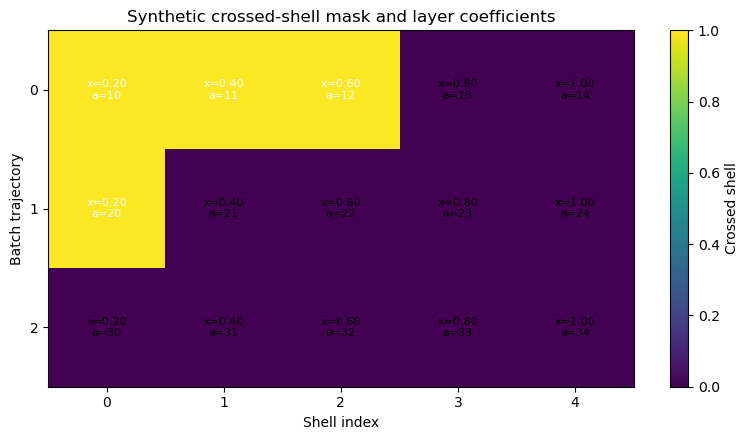

PASSED: plot_crossed_shell_map()


In [10]:
run_notebook_call('plot_crossed_shell_map()', lambda: TEST_MODULE.plot_crossed_shell_map())


## Plot: `plot_flipped_segments()`

**What is checked:** Flipped segments behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_layers_flipped_segments.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_flipped_segments()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_layers_flipped_segments.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_flipped_segments() ...
Saved plot: V:\output\test\earth\test7_layers\plot_flipped_segments_figure_001.png


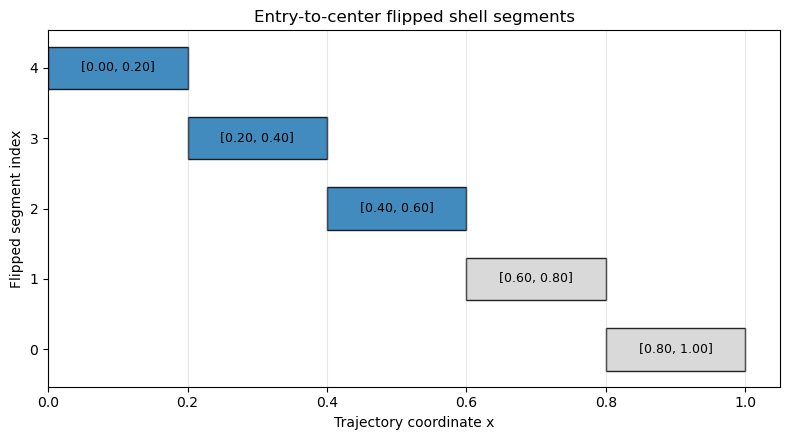

PASSED: plot_flipped_segments()


In [11]:
run_notebook_call('plot_flipped_segments()', lambda: TEST_MODULE.plot_flipped_segments())
